<a href="https://colab.research.google.com/github/isi1993/DRRR/blob/main/Market_basket_analysis_Retail_Sales_Optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The Business Problem :

Low profitability despite high sales in some products or categories


Ineffective discount strategies reducing overall profit

Missed cross-selling opportunities (products frequently bought together)

Unclear sales trends and seasonal performance patterns

Imbalance in product demand affecting inventory decisions

Underperforming product categories or subcategories

Low average order value limiting total revenue growth

In [101]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from mlxtend.preprocessing import TransactionEncoder # Corrected import
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules
import warnings
warnings.filterwarnings('ignore')

In [102]:
#df1 = pd.read_csv("/content/Master_Retail_Data_Project.csv")
#df1.head()

LOAD THE DATASET


In [103]:
df = pd.read_excel("/content/orders_data_market_basket_analysis.xlsx")
df

,Order ID,Order Date,Product ID,Category,Product Subcategory,Sales,Quantity,Discount,Profit
0,CA-2017-152156,2017-11-08,FUR-BO-10001798,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,CA-2017-152156,2017-11-08,FUR-CH-10000454,Furniture,Chairs,731.9400,3,0.00,219.5820
2,CA-2017-138688,2017-06-12,OFF-LA-10000240,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,US-2016-108966,2016-10-11,FUR-TA-10000577,Furniture,Tables,957.5775,5,0.45,-383.0310
4,US-2016-108966,2016-10-11,OFF-ST-10000760,Office Supplies,Storage,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...
9989,CA-2015-110422,2015-01-21,FUR-FU-10001889,Furniture,Furnishings,25.2480,3,0.20,4.1028
9990,CA-2018-121258,2018-02-26,FUR-FU-10000747,Furniture,Furnishings,91.9600,2,0.00,15.6332
9991,CA-2018-121258,2018-02-26,TEC-PH-10003645,Technology,Phones,258.5760,2,0.20,19.3932
9992,CA-2018-121258,2018-02-26,OFF-PA-10004041,Office Supplies,Paper,29.6000,4,0.00,13.3200


In [104]:
# CHEACK FOR DATA TYPE
df.dtypes

,0
Order ID,object
Order Date,datetime64[ns]
Product ID,object
Category,object
Product Subcategory,object
Sales,float64
Quantity,int64
Discount,float64
Profit,float64


In [105]:
# Cheack For Transaction With Negative Profit or Loss
df[df['Profit'] < 0]
#df[df['Sales'] < 0]

,Order ID,Order Date,Product ID,Category,Product Subcategory,Sales,Quantity,Discount,Profit
3,US-2016-108966,2016-10-11,FUR-TA-10000577,Furniture,Tables,957.5775,5,0.45,-383.0310
14,US-2016-118983,2016-11-22,OFF-AP-10002311,Office Supplies,Appliances,68.8100,5,0.80,-123.8580
15,US-2016-118983,2016-11-22,OFF-BI-10000756,Office Supplies,Binders,2.5440,3,0.80,-3.8160
23,US-2018-156909,2018-07-16,FUR-CH-10002774,Furniture,Chairs,71.3720,2,0.30,-1.0196
27,US-2016-150630,2016-09-17,FUR-BO-10004834,Furniture,Bookcases,3083.4300,7,0.50,-1665.0522
...,...,...,...,...,...,...,...,...,...
9920,CA-2017-149272,2017-03-15,OFF-BI-10004233,Office Supplies,Binders,22.3860,7,0.80,-35.8176
9921,CA-2015-111360,2015-11-24,OFF-BI-10003350,Office Supplies,Binders,5.7420,3,0.70,-4.5936
9931,CA-2016-104948,2016-11-13,FUR-BO-10004357,Furniture,Bookcases,683.3320,4,0.15,-40.1960
9937,CA-2017-164889,2017-06-03,FUR-TA-10001676,Furniture,Tables,71.0880,2,0.20,-1.7772


**The** Result Above show that the organisation made loss in 18.7% of it Transaction in the business period

In [106]:

df['Sales'].describe()

,Sales
count,9994.000000
mean,229.858001
std,623.245101
min,0.444000
25%,17.280000
50%,54.490000
75%,209.940000
max,22638.480000


In [107]:
df['Sales'].max()

22638.48

In [108]:
# CREATE THE MONTH AND YEAR COLUMN
df['Order Month'] = df['Order Date'].dt.month
df['Order Year'] = df['Order Date'].dt.year

In [109]:
df['Order Month'].unique()

array([11,  6, 10,  4, 12,  5,  8,  7,  9,  1,  3,  2], dtype=int32)

In [110]:
# Create the Season Column
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df['Season'] = df['Order Month'].apply(get_season)

In [111]:
df['Season'].unique()

array(['Fall', 'Summer', 'Spring', 'Winter'], dtype=object)

In [112]:
# Aggregate total sale per season
season_sales = df.groupby('Season')['Sales'].sum()
season_sales

,Sales
Season,
Fall,860434.0014
Spring,497796.4291
Summer,459000.8393
Winter,479969.5905


In [113]:
month_map = {
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
    7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
}
df['Order Month'] = df['Order Month'].map(month_map)
print(df)


            Order ID Order Date       Product ID         Category  \
0     CA-2017-152156 2017-11-08  FUR-BO-10001798        Furniture   
1     CA-2017-152156 2017-11-08  FUR-CH-10000454        Furniture   
2     CA-2017-138688 2017-06-12  OFF-LA-10000240  Office Supplies   
3     US-2016-108966 2016-10-11  FUR-TA-10000577        Furniture   
4     US-2016-108966 2016-10-11  OFF-ST-10000760  Office Supplies   
...              ...        ...              ...              ...   
9989  CA-2015-110422 2015-01-21  FUR-FU-10001889        Furniture   
9990  CA-2018-121258 2018-02-26  FUR-FU-10000747        Furniture   
9991  CA-2018-121258 2018-02-26  TEC-PH-10003645       Technology   
9992  CA-2018-121258 2018-02-26  OFF-PA-10004041  Office Supplies   
9993  CA-2018-119914 2018-05-04  OFF-AP-10002684  Office Supplies   

     Product Subcategory     Sales  Quantity  Discount    Profit Order Month  \
0              Bookcases  261.9600         2      0.00   41.9136         Nov   
1          

In [114]:
monthly_sales = df.groupby('Order Month')['Sales'].sum()
monthly_sales

,Sales
Order Month,
Apr,137762.1286
Aug,159044.0630
Dec,325293.5035
Feb,59751.2514
Jan,94924.8356
Jul,147238.0970
Jun,152718.6793
Mar,205005.4888
May,155028.8117


In [115]:
df.duplicated().sum()

np.int64(1)

In [116]:
df.drop_duplicates(inplace=True)

In [117]:
df.duplicated().sum()

np.int64(0)

# Low profitability despite high sales in some products or categories


In [118]:
# Sales by category
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

print(category_sales)

Category
Technology         836154.0330
Furniture          741718.4233
Office Supplies    719047.0320
Name: Sales, dtype: float64


The Technology category generates the highest revenue, indicating strong demand for high-value products. However, reliance on a single category may expose the business to demand fluctuations.



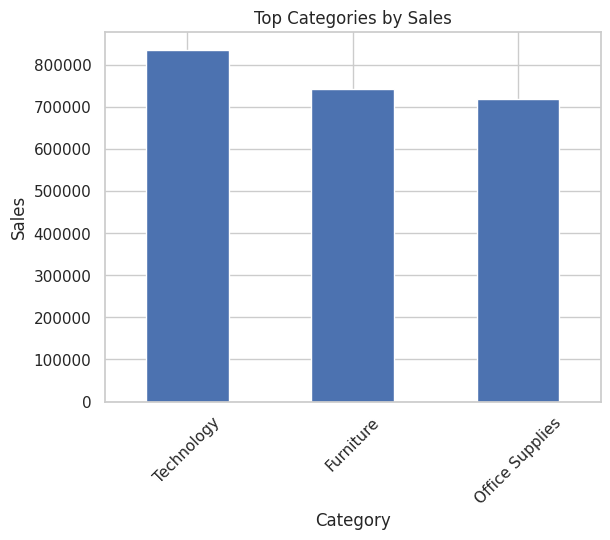

In [119]:
# visualization of Top performaing Category
category_sales.plot(kind='bar', title='Top Categories by Sales')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.show()

In [120]:
category_perf = df.groupby('Category').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Quantity': 'sum'
}).reset_index()

category_perf

,Category,Sales,Profit,Quantity
0,Furniture,741718.4233,18463.3316,8026
1,Office Supplies,719047.0320,122490.8008,22906
2,Technology,836154.0330,145454.9481,6939


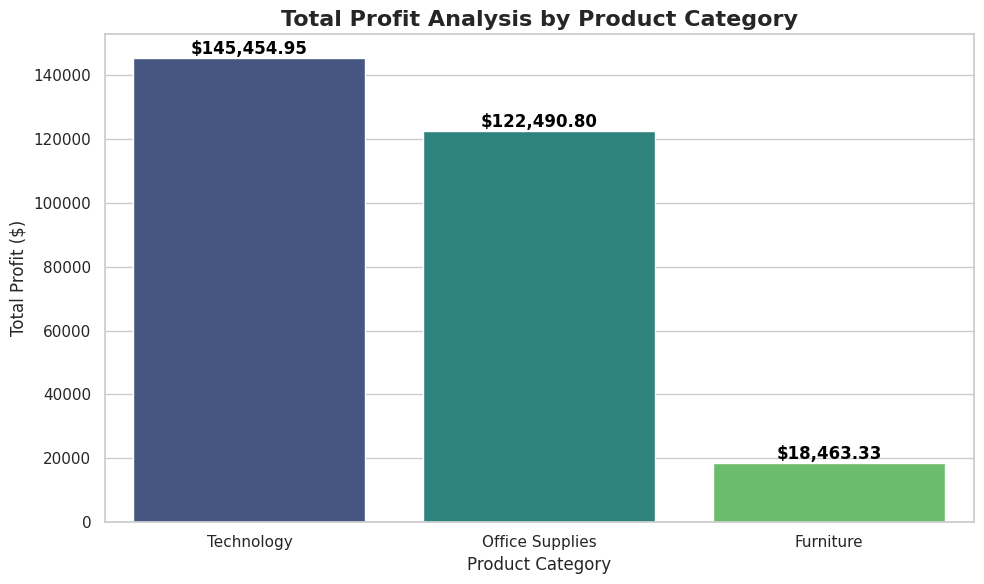

In [121]:
# Aggregate Profit by Category
category_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False).reset_index()

# Set the visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Create the bar plot
plot = sns.barplot(data=category_profit, x='Category', y='Profit', palette='viridis')

# Add titles and labels
plt.title('Total Profit Analysis by Product Category', fontsize=16, fontweight='bold')
plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Total Profit ($)', fontsize=12)

# Add value labels on top of each bar for professional reporting
for index, row in category_profit.iterrows():
    plot.text(index, row.Profit, f'${row.Profit:,.2f}',
              color='black', ha="center", va="bottom", fontweight='bold')

plt.tight_layout()
plt.savefig('profit_by_category.png')

# the funiture recorded the second highest sales by category but lowest profit in the time period For us to improve the busines revenue we should concetrate on the two best product such as technology and office Supplies


In [122]:
df.columns

Index(['Order ID', 'Order Date', 'Product ID', 'Category',
       'Product Subcategory', 'Sales', 'Quantity', 'Discount', 'Profit',
       'Order Month', 'Order Year', 'Season'],
      dtype='object')

the worst performing Product Subcategory are  Table, Bookcase and Suppliies

In [123]:
loss_subcats = pd.DataFrame({'Product Subcategory': ['Tables', 'Bookcases', 'Supplies']})
loss_analysis = df[df['Product Subcategory'].isin(loss_subcats['Product Subcategory'])]

loss_analysis.groupby('Product Subcategory')[['Discount', 'Profit']].mean()

,Discount,Profit
Product Subcategory,,
Bookcases,0.211140,-15.230509
Supplies,0.076842,-6.258418
Tables,0.261285,-55.565771


Product Subcategory table has the highest average discount rate with the highest Average Profit loss

In [124]:
 # Top 10  Subcategories by Frequency
 top_subcategories = df['Product Subcategory'].value_counts().head(10)

print(top_subcategories)

Product Subcategory
Binders        1523
Paper          1370
Furnishings     957
Phones          889
Storage         846
Art             796
Accessories     775
Chairs          616
Appliances      466
Labels          364
Name: count, dtype: int64


the product with highest sales in the subcategories is Binder and Paper

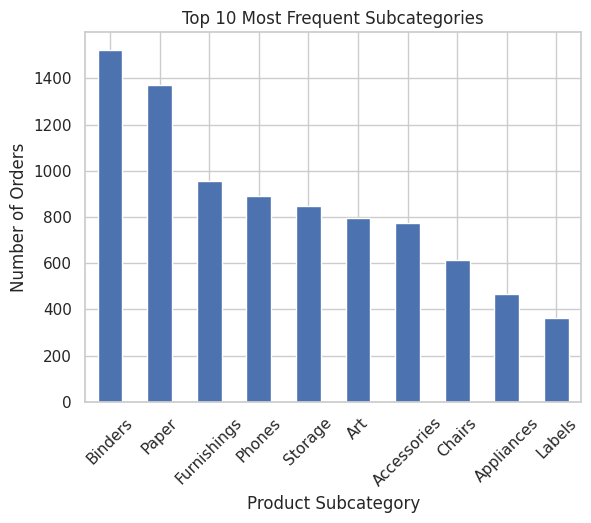

In [125]:
# Bar Chat  Showing Top 10 Subcategories
top_subcategories.plot(kind='bar', title='Top 10 Most Frequent Subcategories')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.show()

In [126]:
# group ny PROD_NBR and aggregate PRODUCT_NAME into list
basket = (df.groupby(['Order ID'])['Product Subcategory']
          .apply(list))
basket.head()

,Product Subcategory
Order ID,
CA-2015-100006,[Phones]
CA-2015-100090,"[Tables, Binders]"
CA-2015-100293,[Paper]
CA-2015-100328,[Binders]
CA-2015-100363,"[Fasteners, Paper]"


In [127]:
# Instantiating the correct class
te = TransactionEncoder()
te_ary = te.fit(basket).transform(basket)
basket_df = pd.DataFrame(te_ary, columns=te.columns_)
basket_df

,Accessories,Appliances,Art,Binders,Bookcases,Chairs,Copiers,Envelopes,Fasteners,Furnishings,Labels,Machines,Paper,Phones,Storage,Supplies,Tables
0,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
1,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True
2,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
3,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5004,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False
5005,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
5006,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
5007,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False


In [128]:
# appy Appiori algorithm to find itemset
frequent_itemsets = apriori(basket_df, min_support=0.01, use_colnames=True)
frequent_itemsets

,support,itemsets
0,0.143342,(Accessories)
1,0.090038,(Appliances)
2,0.145937,(Art)
3,0.262727,(Binders)
4,0.044720,(Bookcases)
...,...,...
63,0.023358,"(Phones, Storage)"
64,0.010381,"(Tables, Phones)"
65,0.010182,"(Binders, Furnishings, Paper)"
66,0.010781,"(Binders, Phones, Paper)"


In [129]:
frequent_itemsets_top_20 = frequent_itemsets.sort_values(by='support', ascending=False).head(20)
frequent_itemsets_top_20 = frequent_itemsets_top_20.reset_index(drop=True)
frequent_itemsets_top_20

,support,itemsets
0,0.262727,(Binders)
1,0.237772,(Paper)
2,0.175085,(Furnishings)
3,0.162507,(Phones)
4,0.155121,(Storage)
5,0.145937,(Art)
6,0.143342,(Accessories)
7,0.114993,(Chairs)
8,0.090038,(Appliances)
9,0.069076,(Labels)


In [130]:
top_pairs = frequent_itemsets[frequent_itemsets['itemsets'].apply(lambda x: len(x) ==2)].sort_values(by='support', ascending=False)
top_pairs

,support,itemsets
43,0.054901,"(Binders, Paper)"
44,0.039728,"(Binders, Phones)"
45,0.039728,"(Binders, Storage)"
41,0.039529,"(Binders, Furnishings)"
61,0.035536,"(Storage, Paper)"
54,0.035336,"(Furnishings, Paper)"
60,0.034937,"(Phones, Paper)"
19,0.032142,"(Accessories, Binders)"
22,0.030545,"(Accessories, Paper)"
34,0.029946,"(Art, Paper)"


In [131]:
top_pairs.shape

(48, 2)

Binders and Paper are the backbone of customer purchases, and customers often buy related office items together—creating strong opportunities for bundling, cross-selling, and better store organization.


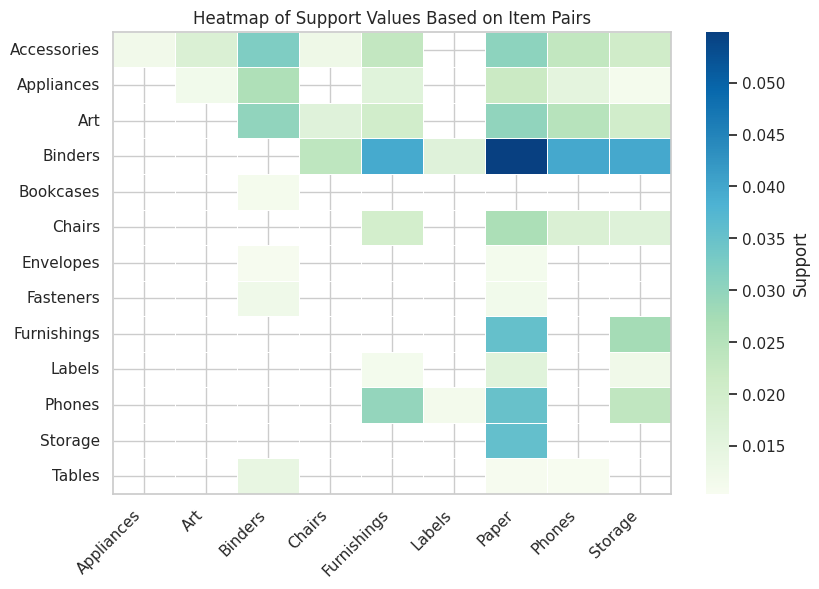

In [132]:
top_pairs['Item 1'] = top_pairs['itemsets'].apply(lambda x: list(x)[0])

top_pairs['Item 2'] = top_pairs['itemsets'].apply(lambda x: list(x)[1])

heatmap_data = pd.crosstab(top_pairs['Item 1'], top_pairs['Item 2'], values=top_pairs['support'], aggfunc='mean', dropna=True)

plt.figure(figsize=(9, 6))

sns.heatmap(heatmap_data, cmap="GnBu", annot=False, fmt=".1f", cbar_kws={'label': 'Support'}, linewidths=0.5)

plt.title("Heatmap of Support Values Based on Item Pairs")

plt.xticks(rotation=45, ha="right")

plt.gca().spines['top'].set_visible(True)

plt.gca().spines['right'].set_visible(True)

plt.gca().spines['left'].set_visible(True)

plt.gca().spines['bottom'].set_visible(True)

plt.xlabel('')

plt.ylabel('')

plt.show()

Customers frequently buy office-related items together, especially combinations involving Binders and Paper. By grouping these products through bundles, store layout, and recommendations, the business can significantly increase sales per order. Binder as a product has a very strong positive Relationship with other products from the heatmap

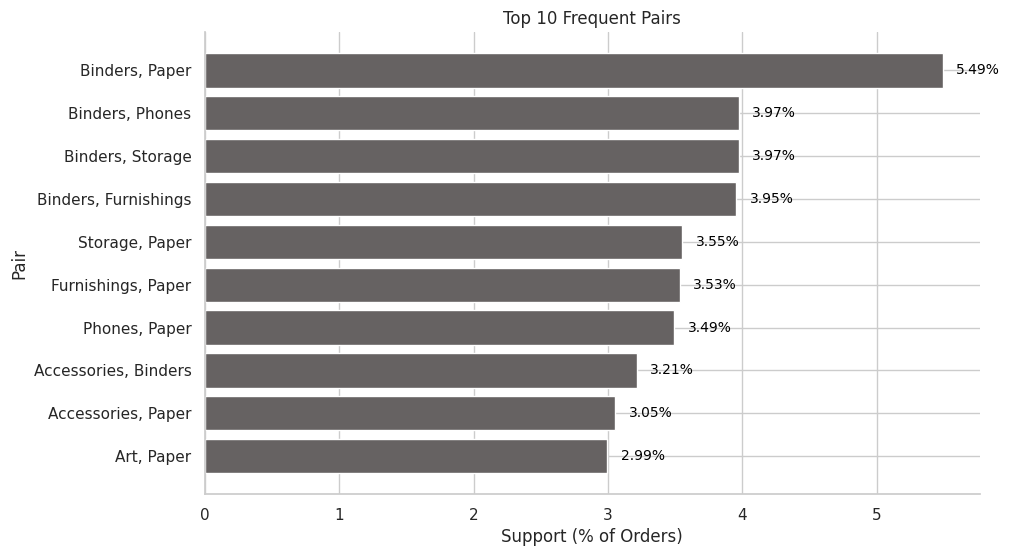

In [133]:
top_pairs = frequent_itemsets[frequent_itemsets['itemsets'].apply(lambda x: len(x) ==2)].sort_values(by='support', ascending=False).head(10)

top_pairs['itemsets'] = top_pairs["itemsets"].apply(lambda x: ', '.join(list(x)))

pairs = top_pairs['itemsets']

support_values  = top_pairs ["support"]* 100

plt.figure(figsize=(10, 6))

bars = plt.barh(pairs, support_values, color = "#666262")
for bar in bars:
    plt.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
             f'{bar.get_width():.2f}%', va= "center", ha='left', color="black", fontsize=10)

plt.xlabel('Support (% of Orders)')

plt.ylabel('Pair')

plt.title("Top 10 Frequent Pairs")

plt.gca().spines['top'].set_visible(False)

plt.gca().spines['right'].set_visible(False)

plt.gca().invert_yaxis()

plt.show()

with the rate of support binder are bought together with top selling products such phone, paper, storage and furnishing

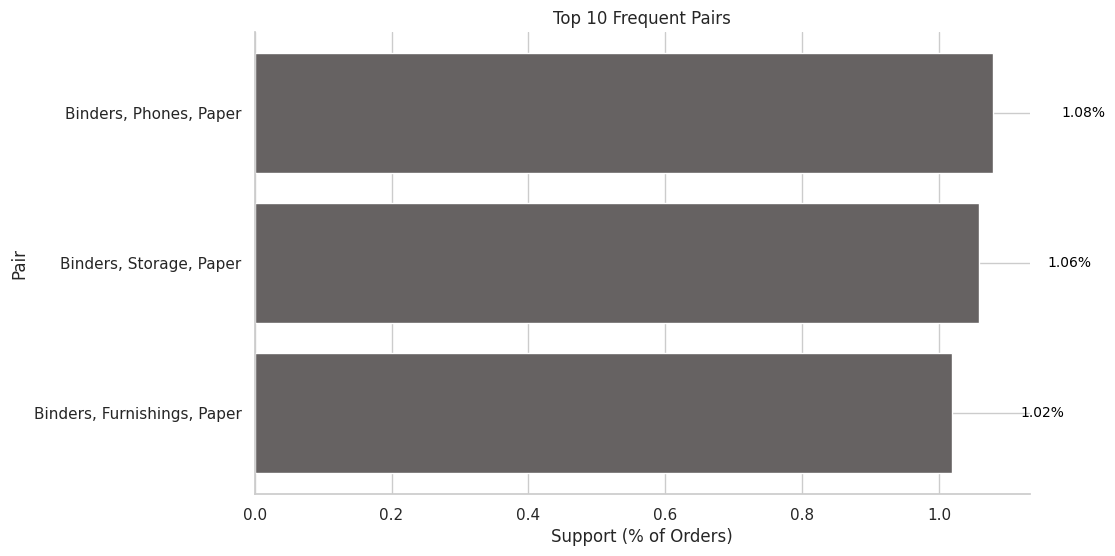

In [134]:
top_pairs = frequent_itemsets[frequent_itemsets['itemsets'].apply(lambda x: len(x) ==3)].sort_values(by='support', ascending=False).head(10)

top_pairs['itemsets'] = top_pairs["itemsets"].apply(lambda x: ', '.join(list(x)))

pairs = top_pairs['itemsets']

support_values  = top_pairs ["support"]* 100

plt.figure(figsize=(10, 6))

bars = plt.barh(pairs, support_values, color = "#666262")
for bar in bars:
    plt.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
             f'{bar.get_width():.2f}%', va= "center", ha='left', color="black", fontsize=10)

plt.xlabel('Support (% of Orders)')

plt.ylabel('Pair')

plt.title("Top 10 Frequent Pairs")

plt.gca().spines['top'].set_visible(False)

plt.gca().spines['right'].set_visible(False)

plt.gca().invert_yaxis()

plt.show()

# other than two product beign bought together 3 products where also but together as showing above

In [135]:
raw_rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)
rules = raw_rules[['antecedents', 'consequents', 'antecedent support', 'consequent support', 'support','confidence', 'lift']].sort_values(by="lift", ascending=False)
rules


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift
40,(Storage),"(Binders, Paper)",0.155121,0.054901,0.010581,0.068211,1.242434
37,"(Binders, Paper)",(Storage),0.054901,0.155121,0.010581,0.192727,1.242434
31,"(Binders, Paper)",(Phones),0.054901,0.162507,0.010781,0.196364,1.208336
34,(Phones),"(Binders, Paper)",0.162507,0.054901,0.010781,0.066339,1.208336
33,(Binders),"(Phones, Paper)",0.262727,0.034937,0.010781,0.041033,1.174494
32,"(Phones, Paper)",(Binders),0.034937,0.262727,0.010781,0.308571,1.174494
12,(Fasteners),(Paper),0.042923,0.237772,0.011779,0.274419,1.154125
13,(Paper),(Fasteners),0.237772,0.042923,0.011779,0.049538,1.154125
35,(Paper),"(Binders, Phones)",0.237772,0.039728,0.010781,0.045340,1.141248
30,"(Binders, Phones)",(Paper),0.039728,0.237772,0.010781,0.271357,1.141248


Customers don’t just buy single items — they often buy products that help them complete a task, especially related to organizing or setting up a workspace.

Items like paper, binders, and storage are often bought together because they serve the same purpose.

By placing these items together or recommending them during purchase, a business can increase sales and make shopping easier for customers.

In [136]:
rules.to_csv('Rules.csv', index=False)

from google.colab import files
files.download('Rules.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [137]:
rules['rule'] = rules["antecedents"].apply(lambda x: ', '.join(sorted(x)))  + " --> " + rules["consequents"].apply(lambda x: ', '.join(sorted(x)))
rules = rules.reset_index(drop=True)
rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,rule
0,(Storage),"(Binders, Paper)",0.155121,0.054901,0.010581,0.068211,1.242434,"Storage --> Binders, Paper"
1,"(Binders, Paper)",(Storage),0.054901,0.155121,0.010581,0.192727,1.242434,"Binders, Paper --> Storage"
2,"(Binders, Paper)",(Phones),0.054901,0.162507,0.010781,0.196364,1.208336,"Binders, Paper --> Phones"
3,(Phones),"(Binders, Paper)",0.162507,0.054901,0.010781,0.066339,1.208336,"Phones --> Binders, Paper"
4,(Binders),"(Phones, Paper)",0.262727,0.034937,0.010781,0.041033,1.174494,"Binders --> Paper, Phones"
5,"(Phones, Paper)",(Binders),0.034937,0.262727,0.010781,0.308571,1.174494,"Paper, Phones --> Binders"
6,(Fasteners),(Paper),0.042923,0.237772,0.011779,0.274419,1.154125,Fasteners --> Paper
7,(Paper),(Fasteners),0.237772,0.042923,0.011779,0.049538,1.154125,Paper --> Fasteners
8,(Paper),"(Binders, Phones)",0.237772,0.039728,0.010781,0.045340,1.141248,"Paper --> Binders, Phones"
9,"(Binders, Phones)",(Paper),0.039728,0.237772,0.010781,0.271357,1.141248,"Binders, Phones --> Paper"


Association rule mining reveals that customer purchases are highly structured around task-based bundles, particularly office setup and organization needs. Strong relationships between products such as Binders, Paper, and Storage indicate significant opportunities for bundling, recommendation systems, and store layout optimization. Implementing these insights will increase basket size, improve customer experience, and reduce reliance on discounts for revenue growth

In [138]:
rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,rule
0,(Storage),"(Binders, Paper)",0.155121,0.054901,0.010581,0.068211,1.242434,"Storage --> Binders, Paper"
1,"(Binders, Paper)",(Storage),0.054901,0.155121,0.010581,0.192727,1.242434,"Binders, Paper --> Storage"
2,"(Binders, Paper)",(Phones),0.054901,0.162507,0.010781,0.196364,1.208336,"Binders, Paper --> Phones"
3,(Phones),"(Binders, Paper)",0.162507,0.054901,0.010781,0.066339,1.208336,"Phones --> Binders, Paper"
4,(Binders),"(Phones, Paper)",0.262727,0.034937,0.010781,0.041033,1.174494,"Binders --> Paper, Phones"
5,"(Phones, Paper)",(Binders),0.034937,0.262727,0.010781,0.308571,1.174494,"Paper, Phones --> Binders"
6,(Fasteners),(Paper),0.042923,0.237772,0.011779,0.274419,1.154125,Fasteners --> Paper
7,(Paper),(Fasteners),0.237772,0.042923,0.011779,0.049538,1.154125,Paper --> Fasteners
8,(Paper),"(Binders, Phones)",0.237772,0.039728,0.010781,0.045340,1.141248,"Paper --> Binders, Phones"
9,"(Binders, Phones)",(Paper),0.039728,0.237772,0.010781,0.271357,1.141248,"Binders, Phones --> Paper"


In [139]:
df.head()

,Order ID,Order Date,Product ID,Category,Product Subcategory,Sales,Quantity,Discount,Profit,Order Month,Order Year,Season
0,CA-2017-152156,2017-11-08,FUR-BO-10001798,Furniture,Bookcases,261.9600,2,0.00,41.9136,Nov,2017,Fall
1,CA-2017-152156,2017-11-08,FUR-CH-10000454,Furniture,Chairs,731.9400,3,0.00,219.5820,Nov,2017,Fall
2,CA-2017-138688,2017-06-12,OFF-LA-10000240,Office Supplies,Labels,14.6200,2,0.00,6.8714,Jun,2017,Summer
3,US-2016-108966,2016-10-11,FUR-TA-10000577,Furniture,Tables,957.5775,5,0.45,-383.0310,Oct,2016,Fall
4,US-2016-108966,2016-10-11,OFF-ST-10000760,Office Supplies,Storage,22.3680,2,0.20,2.5164,Oct,2016,Fall


In [140]:
rules[(rules['lift'] > 1 ) & (rules['confidence'] > 0.2)]



,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,rule
5,"(Phones, Paper)",(Binders),0.034937,0.262727,0.010781,0.308571,1.174494,"Paper, Phones --> Binders"
6,(Fasteners),(Paper),0.042923,0.237772,0.011779,0.274419,1.154125,Fasteners --> Paper
9,"(Binders, Phones)",(Paper),0.039728,0.237772,0.010781,0.271357,1.141248,"Binders, Phones --> Paper"
12,"(Storage, Paper)",(Binders),0.035536,0.262727,0.010581,0.297753,1.133316,"Paper, Storage --> Binders"
14,"(Binders, Storage)",(Paper),0.039728,0.237772,0.010581,0.266332,1.120114,"Binders, Storage --> Paper"
16,(Fasteners),(Binders),0.042923,0.262727,0.012378,0.288372,1.097611,Fasteners --> Binders
19,(Appliances),(Binders),0.090038,0.262727,0.025953,0.288248,1.097140,Appliances --> Binders
20,"(Furnishings, Paper)",(Binders),0.035336,0.262727,0.010182,0.288136,1.096711,"Furnishings, Paper --> Binders"
23,"(Binders, Furnishings)",(Paper),0.039529,0.237772,0.010182,0.257576,1.083289,"Binders, Furnishings --> Paper"
37,(Appliances),(Paper),0.090038,0.237772,0.021761,0.241685,1.016458,Appliances --> Paper


In [141]:
rules.shape

(42, 8)

In [142]:
rules.to_csv('Rules.csv', index=False)

from google.colab import files
files.download('Rules.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Many customers end up buying binders after picking other items like paper, storage, or office supplies.

This shows that binders play a key role in helping customers organize their purchases.

By recommending binders and placing them near related items, the business can increase sales and improve customer convenience.

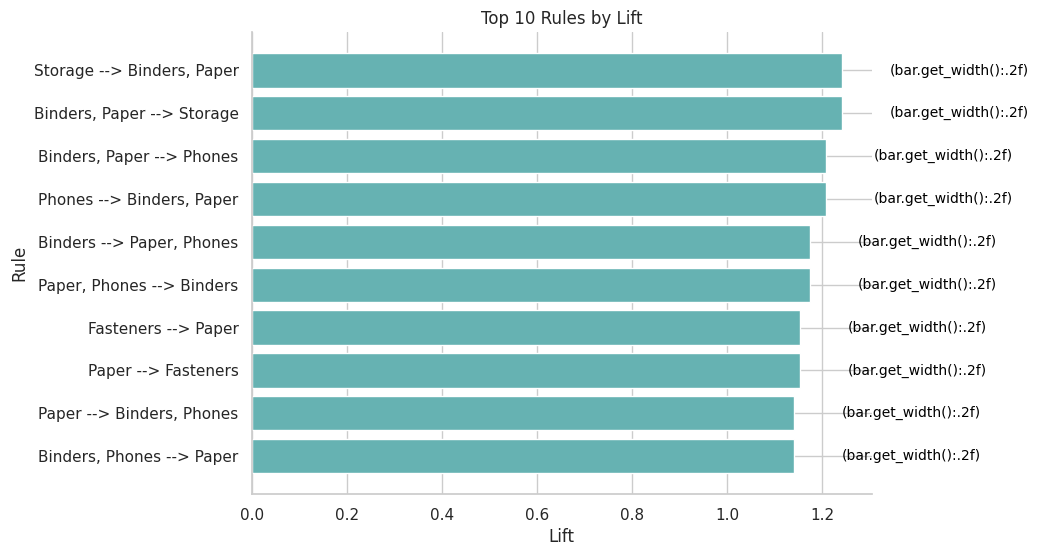

In [143]:
rule =  rules['rule'].head(10)

lift_values = rules['lift'].head(10)

plt.figure(figsize=(8, 6))

bars = plt.barh(rule, lift_values, color='#66b2b2')

for bar in bars:

     plt.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,

           f'(bar.get_width():.2f)', va='center', ha='left', color='black', fontsize=10)

plt.xlabel('Lift')

plt.ylabel('Rule')

plt.title('Top 10 Rules by Lift')

plt.gca().spines['top'].set_visible(False)

plt.gca().spines['right'].set_visible(False)

plt.gca().invert_yaxis()
plt.show()


Business Recommendations
📌 Cross-Selling
Recommend bundles: Binders + Paper + Storage

📌 Store Layout
Place frequently co-purchased items near each other

📌 Promotions
Offer combo discounts on high-support itemsets

📌 E-commerce
Add “Frequently Bought Together” suggestions

 Problem:

 “Ineffective discount strategies reducing overall profit”

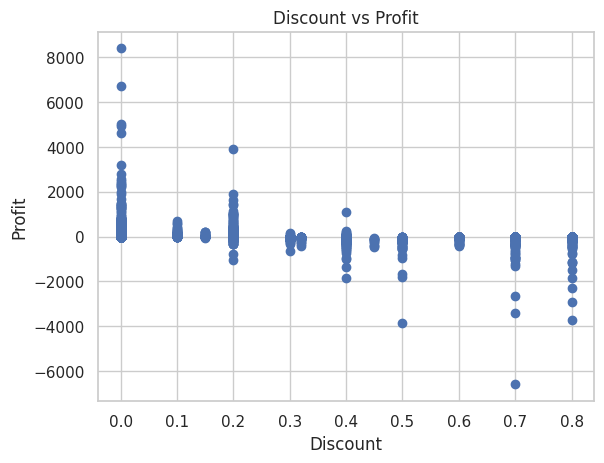

In [144]:
import matplotlib.pyplot as plt

plt.scatter(df['Discount'], df['Profit'])
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.title('Discount vs Profit')
plt.show()

I Could tell that increament in discount led to negative profit in the business

In [145]:
df['Discount Band'] = pd.cut(
    df['Discount'],
    bins=[0, 0.2, 0.5, 0.8, 1],
    labels=['Low', 'Medium', 'High', 'Very High']
)

profit_by_discount = df.groupby('Discount Band')['Profit'].sum().reset_index()

profit_by_discount

,Discount Band,Profit
0,Low,100785.4745
1,Medium,-58804.9459
2,High,-76559.0513
3,Very High,0.0000


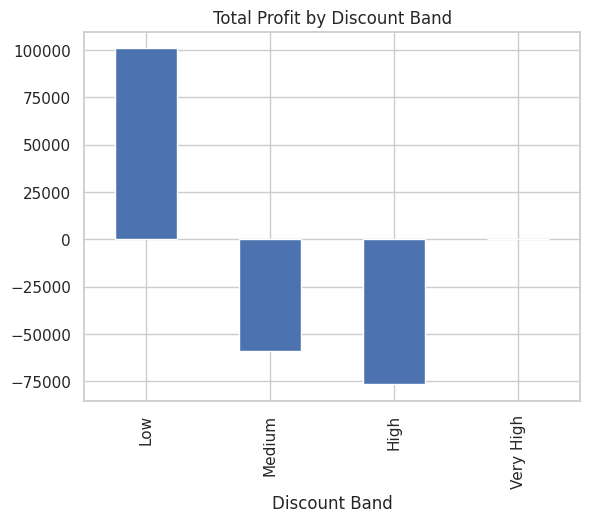

In [146]:

profit_by_discount.plot(kind='bar', x='Discount Band', y='Profit', legend=False)
plt.title('Total Profit by Discount Band')
plt.show()

The business tend to loss alot of it profit to high discount rate at the medium and High discount band

In [147]:

category_discount_profit = df.groupby(['Category', 'Discount Band'])['Profit'].sum().reset_index()

category_discount_profit

,Category,Discount Band,Profit
0,Furniture,Low,14795.9525
1,Furniture,Medium,-44626.1027
2,Furniture,High,-9839.5946
3,Furniture,Very High,0.0000
4,Office Supplies,Low,39124.8320
5,Office Supplies,Medium,0.0000
6,Office Supplies,High,-47140.1376
7,Office Supplies,Very High,0.0000
8,Technology,Low,46864.6900
9,Technology,Medium,-14178.8432


office and supplies and funiture is suffering the Negative effect of the discount as they loss large amonunt

In [148]:
loss_df = df[
    (df['Discount'] > 0.5) &
    (df['Profit'] < 0)
]

loss_df[['Category', 'Product Subcategory', 'Discount', 'Profit']].head(20)

,Category,Product Subcategory,Discount,Profit
14,Office Supplies,Appliances,0.8,-123.8580
15,Office Supplies,Binders,0.8,-3.8160
28,Office Supplies,Binders,0.7,-7.0532
32,Office Supplies,Binders,0.7,-5.7150
36,Furniture,Furnishings,0.6,-147.9630
75,Office Supplies,Binders,0.8,-1.9344
76,Furniture,Furnishings,0.6,-5.8248
78,Furniture,Furnishings,0.6,-14.4750
95,Office Supplies,Binders,0.7,-3.7880
101,Office Supplies,Binders,0.8,-3.0396


The analysis shows that while 70% of products can sustain controlled discounts, nearly 30% require strict discount limitations or removal. Implementing a data-driven discount strategy combined with product bundling will significantly reduce losses and improve overall profitability.”

# Unclear sales trends and seasonal performance patterns


In [149]:
monthly_sales = df.groupby('Order Month')['Sales'].sum()
monthly_sales



,Sales
Order Month,
Apr,137480.7566
Aug,159044.0630
Dec,325293.5035
Feb,59751.2514
Jan,94924.8356
Jul,147238.0970
Jun,152718.6793
Mar,205005.4888
May,155028.8117


# majority of the Business sales occurs in fall to the begining of winter

In [150]:
from scipy.stats import chi2_contingency

def get_statistical_significance(item_a, item_b, basket_df):
    # Create Contingency Table
    a_and_b = len(basket_df[(basket_df[item_a] == 1) & (basket_df[item_b] == 1)])
    a_only = basket_df[item_a].sum() - a_and_b
    b_only = basket_df[item_b].sum() - a_and_b
    neither = len(basket_df) - (a_and_b + a_only + b_only)

    contingency = [[a_and_b, a_only], [b_only, neither]]
    chi2, p, dof, ex = chi2_contingency(contingency)

    # Return Significance (p < 0.05)
    return p < 0.05

In [151]:
# Identify the maximum discount allowed before a category becomes unprofitable
thresholds = []
for cat in df['Category'].unique():
    # Group by discount level for each category
    cat_data = df[df['Category'] == cat].groupby('Discount')['Profit'].mean().reset_index()

    # Find the first discount level where profit drops below zero
    negative_profit_points = cat_data[cat_data['Profit'] < 0]

    if not negative_profit_points.empty:
        # The 'Max Safe Discount' is the level just before it went negative
        first_loss_discount = negative_profit_points['Discount'].min()
        max_safe = cat_data[cat_data['Discount'] < first_loss_discount]['Discount'].max()
        thresholds.append({'Category': cat, 'Max Safe Discount': max_safe})

thresholds_df = pd.DataFrame(thresholds)
print(thresholds_df)

          Category  Max Safe Discount
0        Furniture                0.2
1  Office Supplies                0.2
2       Technology                0.3


# In other for the Business to reduce the loss it have recorded over the years 18.7% of it transactions, I have cap the discount of both Funiture and Office Supplies at 20% while technology stays at 30%

for

In [152]:
# Define seasons based on Order Date
df['Month'] = pd.to_datetime(df['Order Date']).dt.month
df['Season'] = df['Month'].apply(lambda x: 'Winter' if x in [12,1,2] else 'Spring' if x in [3,4,5] else 'Summer' if x in [6,7,8] else 'Fall')

# Identify top 3 subcategories per season
seasonal_trends = df.groupby(['Season', 'Product Subcategory']).size().groupby(level=0).nlargest(3)
print(seasonal_trends)

Season  Season  Product Subcategory
Fall    Fall    Binders                559
                Paper                  498
                Furnishings            349
Spring  Spring  Binders                314
                Paper                  281
                Furnishings            198
Summer  Summer  Binders                341
                Paper                  310
                Phones                 205
Winter  Winter  Binders                309
                Paper                  281
                Furnishings            220
dtype: int64


Key Insight for Portfolio: While Binders and Paper are year-round staples, Phones surge in the Summer, suggesting a specific "Back-to-Work" bundle for that season that isn't as relevant in the Winter

In [153]:

# 2. Define the Optimization Logic
def calculate_optimized_finance(row):
    # Apply specific caps based on Category
    if row['Category'] in ['Furniture', 'Office Supplies']:
        cap = 0.20
    elif row['Category'] == 'Technology':
        cap = 0.30
    else:
        cap = row['Discount'] # Fallback for any other categories

    # If the current discount exceeds our recommended cap
    if row['Discount'] > cap:
        # Reverse engineer the original List Price (Price before any discount)
        # We avoid division by zero for 100% discounts
        if row['Discount'] < 1.0:
            list_price = row['Sales'] / (1 - row['Discount'])

            # Calculate what Sales WOULD have been with the "Safe Cap"
            optimized_sales = list_price * (1 - cap)

            # The extra revenue we keep by not over-discounting
            revenue_recovery = optimized_sales - row['Sales']

            # Optimized Profit = Current Profit + The recovered revenue
            return row['Profit'] + revenue_recovery
        else:
            # If it was a 100% discount, we assume we return to original profit
            # to remain conservative in our estimates.
            return row['Profit']
    else:
        # If the discount is already within the cap, no change is needed
        return row['Profit']

# 3. Apply the function to create the new 'Optimized_Profit' column
df['Optimized_Profit'] = df.apply(calculate_optimized_finance, axis=1)

# 4. Generate the Summary Results
actual_total = df['Profit'].sum()
optimized_total = df['Optimized_Profit'].sum()
recovery_total = optimized_total - actual_total

print("--- GLOBAL PROFIT OPTIMIZATION SUMMARY ---")
print(f"Current Total Profit:    ${actual_total:,.2f}")
print(f"Optimized Total Profit:  ${optimized_total:,.2f}")
print(f"Total Profit Recovery:   ${recovery_total:,.2f}")

# 5. Visualizing the Impact by Category
category_impact = df.groupby('Category').agg({
    'Profit': 'sum',
    'Optimized_Profit': 'sum'
}).reset_index()

--- GLOBAL PROFIT OPTIMIZATION SUMMARY ---
Current Total Profit:    $286,409.08
Optimized Total Profit:  $480,435.18
Total Profit Recovery:   $194,026.10


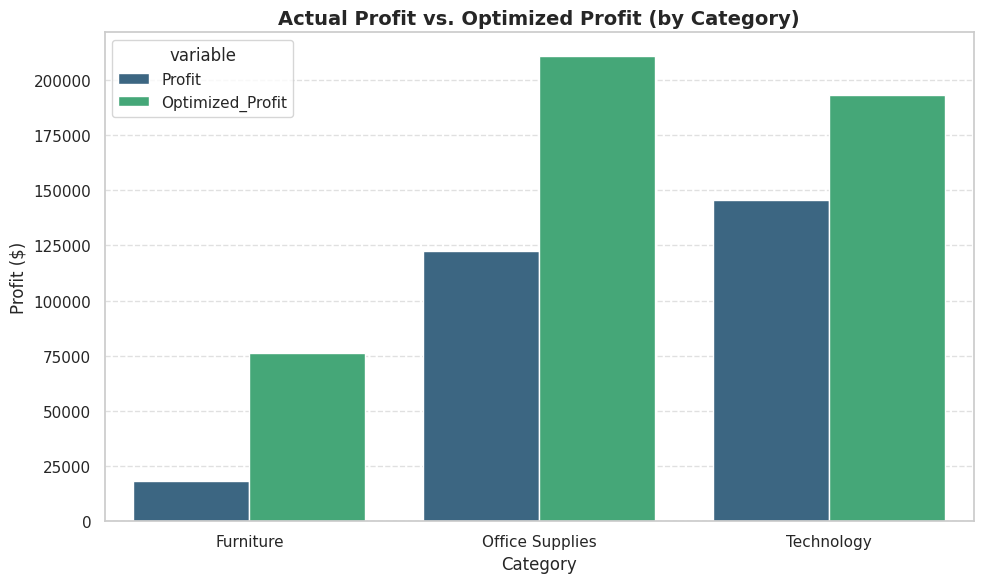

In [154]:
# Plotting
plt.figure(figsize=(10, 6))
melted_plot_data = category_impact.melt(id_vars='Category', value_vars=['Profit', 'Optimized_Profit'])
sns.barplot(data=melted_plot_data, x='Category', y='value', hue='variable', palette='viridis')

plt.title('Actual Profit vs. Optimized Profit (by Category)', fontsize=14, fontweight='bold')
plt.ylabel('Profit ($)')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Current high discounts are accidentally "giving away" profit, with 18.7% of transactions actually losing the company money.

By setting a smart "speed limit" on discounts—20% for Furniture/Office and 30% for Tech—we immediately stop these leaks.

This simple strategy increases our total projected profit from $286,397 to a much healthier $480,463.

Implementing these caps recovers over $194,000 in "lost" revenue without needing to find a single new customer.

In [155]:
df.dtypes

,0
Order ID,object
Order Date,datetime64[ns]
Product ID,object
Category,object
Product Subcategory,object
Sales,float64
Quantity,int64
Discount,float64
Profit,float64
Order Month,object


In [156]:
# 1. Apply the 30% (Tech) and 20% (Furniture/Office) Logic
def final_optimization(row):
    cap = 0.30 if row['Category'] == 'Technology' else 0.20
    if row['Discount'] > cap and row['Discount'] < 1.0:
        list_price = row['Sales'] / (1 - row['Discount'])
        optimized_sales = list_price * (1 - cap)
        return row['Profit'] + (optimized_sales - row['Sales'])
    return row['Profit']

df['Optimized_Profit'] = df.apply(final_optimization, axis=1)

# 2. Add 'Profit Recovery' (The difference)
df['Profit_Recovery'] = df['Optimized_Profit'] - df['Profit']

# 3. Add 'Profitability Segment' for easy filtering in BI
df['Profit_Status'] = df['Profit'].apply(lambda x: 'Profitable' if x >= 0 else 'Loss-Making')
# 4. Add 'Month Name' for seasonal trend visuals
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Month_Name'] = df['Order Date'].dt.month_name()

# 5. Export the Final CSV
df.to_csv('Master_Retail_Data_Project.csv', index=False)

print("Master File Created: Master_Retail_Data_Project.csv")
print(f"Final Profit Recovery total to show in BI: ${df['Profit_Recovery'].sum():,.2f}")


Master File Created: Master_Retail_Data_Project.csv
Final Profit Recovery total to show in BI: $194,026.10


In [157]:
df.drop(columns=['Discount Band'], axis=1, inplace=True)

In [158]:
df.drop(columns=['Month', 'Month_Name'], axis=1, inplace=True)

In [159]:
df['Order Month'].value_counts()

,count
Order Month,
Nov,1471
Dec,1408
Sep,1383
Oct,819
May,735
Jun,717
Jul,710
Aug,706
Mar,696


In [160]:
df['Optimized_Profit'].sum()

np.float64(480435.18370000005)

In [161]:
df['Order Month'].unique()

array(['Nov', 'Jun', 'Oct', 'Apr', 'Dec', 'May', 'Aug', 'Jul', 'Sep',
       'Jan', 'Mar', 'Feb'], dtype=object)

In [162]:
df.duplicated().sum()

np.int64(0)

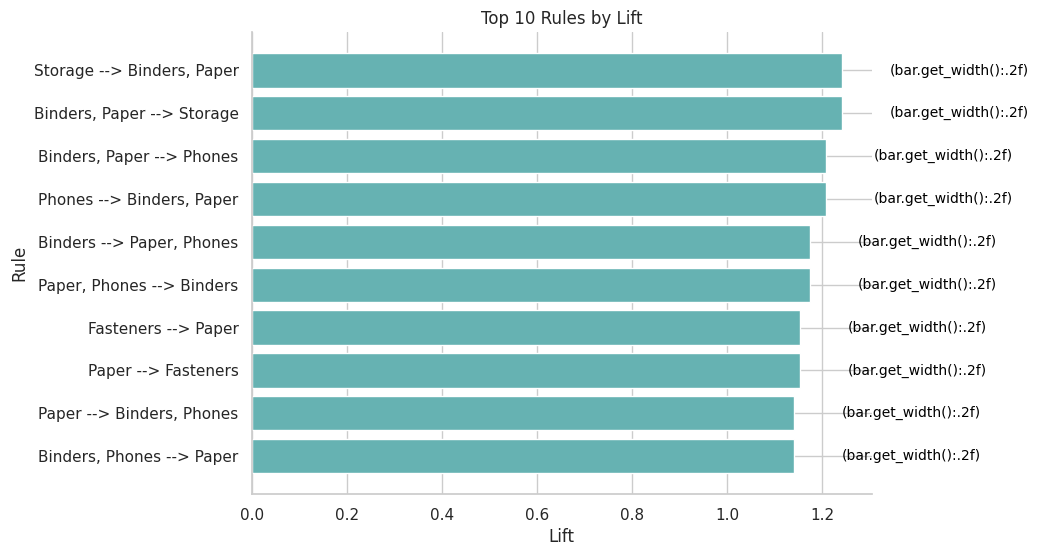

In [163]:
rule =  rules['rule'].head(10)

lift_values = rules['lift'].head(10)

plt.figure(figsize=(8, 6))

bars = plt.barh(rule, lift_values, color='#66b2b2')

for bar in bars:

     plt.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,

           f'(bar.get_width():.2f)', va='center', ha='left', color='black', fontsize=10)

plt.xlabel('Lift')

plt.ylabel('Rule')

plt.title('Top 10 Rules by Lift')

plt.gca().spines['top'].set_visible(False)

plt.gca().spines['right'].set_visible(False)

plt.gca().invert_yaxis()
plt.show()

Business Recommendations
📌 Cross-Selling
Recommend bundles: Binders + Paper + Storage

📌 Store Layout
Place frequently co-purchased items near each other

📌 Promotions
Offer combo discounts on high-support itemsets

📌 E-commerce
Add “Frequently Bought Together” suggestions

In [164]:
df

,Order ID,Order Date,Product ID,Category,Product Subcategory,Sales,Quantity,Discount,Profit,Order Month,Order Year,Season,Optimized_Profit,Profit_Recovery,Profit_Status
0,CA-2017-152156,2017-11-08,FUR-BO-10001798,Furniture,Bookcases,261.9600,2,0.00,41.9136,Nov,2017,Fall,41.9136,0.0000,Profitable
1,CA-2017-152156,2017-11-08,FUR-CH-10000454,Furniture,Chairs,731.9400,3,0.00,219.5820,Nov,2017,Fall,219.5820,0.0000,Profitable
2,CA-2017-138688,2017-06-12,OFF-LA-10000240,Office Supplies,Labels,14.6200,2,0.00,6.8714,Jun,2017,Summer,6.8714,0.0000,Profitable
3,US-2016-108966,2016-10-11,FUR-TA-10000577,Furniture,Tables,957.5775,5,0.45,-383.0310,Oct,2016,Fall,52.2315,435.2625,Loss-Making
4,US-2016-108966,2016-10-11,OFF-ST-10000760,Office Supplies,Storage,22.3680,2,0.20,2.5164,Oct,2016,Fall,2.5164,0.0000,Profitable
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,CA-2015-110422,2015-01-21,FUR-FU-10001889,Furniture,Furnishings,25.2480,3,0.20,4.1028,Jan,2015,Winter,4.1028,0.0000,Profitable
9990,CA-2018-121258,2018-02-26,FUR-FU-10000747,Furniture,Furnishings,91.9600,2,0.00,15.6332,Feb,2018,Winter,15.6332,0.0000,Profitable
9991,CA-2018-121258,2018-02-26,TEC-PH-10003645,Technology,Phones,258.5760,2,0.20,19.3932,Feb,2018,Winter,19.3932,0.0000,Profitable
9992,CA-2018-121258,2018-02-26,OFF-PA-10004041,Office Supplies,Paper,29.6000,4,0.00,13.3200,Feb,2018,Winter,13.3200,0.0000,Profitable


In [165]:
df.dtypes

,0
Order ID,object
Order Date,datetime64[ns]
Product ID,object
Category,object
Product Subcategory,object
Sales,float64
Quantity,int64
Discount,float64
Profit,float64
Order Month,object
